Phase 3
-------
Analyse, Visualise & Report
-------

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [6]:
df=pd.read_csv("AmesHousing.csv")
print(df.head())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

Text(0.5, 1.0, 'Histogram of Mas Vnr Area')

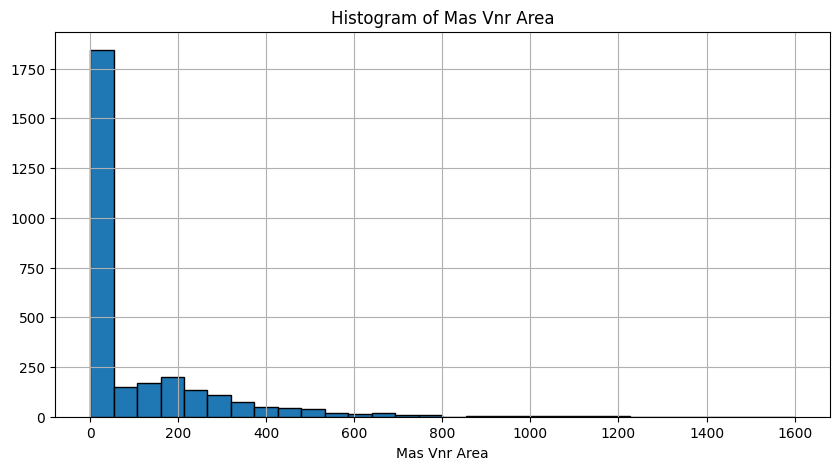

In [7]:
df["Mas Vnr Area"].hist(bins=30,figsize=(10,5),edgecolor="black")
plt.xlabel("Mas Vnr Area")
plt.title("Histogram of Mas Vnr Area")
# it is skewed to right


Text(0.5, 1.0, 'Histogram of Overall Qual')

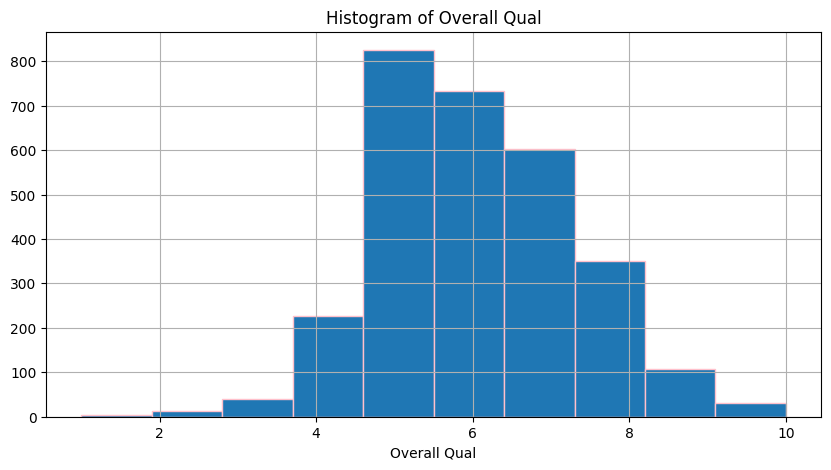

In [8]:
df["Overall Qual"].hist(bins=10,figsize=(10,5),edgecolor="pink",)
plt.xlabel("Overall Qual")
plt.title("Histogram of Overall Qual")
# it is skewed to right

Text(0.5, 1.0, 'KDE Plot of Lot Frontage')

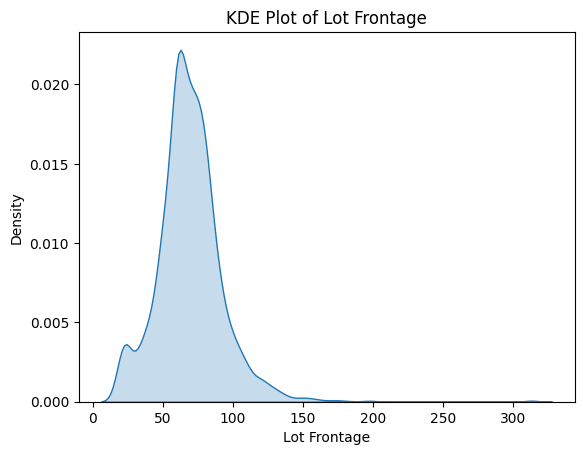

In [9]:
sns.kdeplot(df["Lot Frontage"],fill=True)
plt.title("KDE Plot of Lot Frontage")
# it is skewed to right

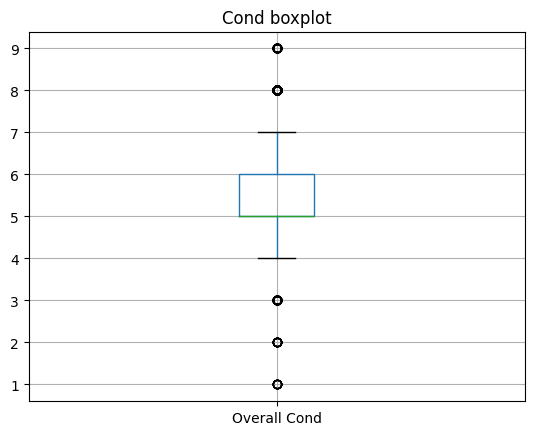

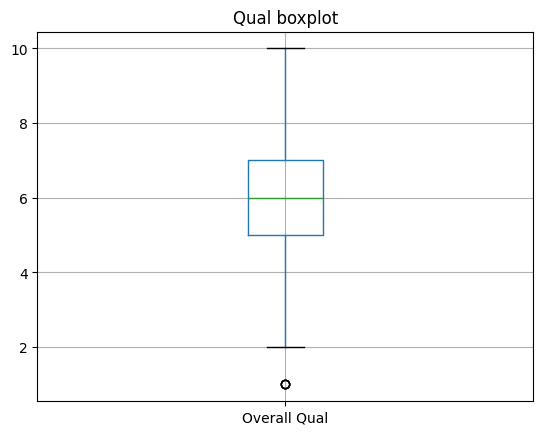

Text(0.5, 1.0, 'overall boxplot')

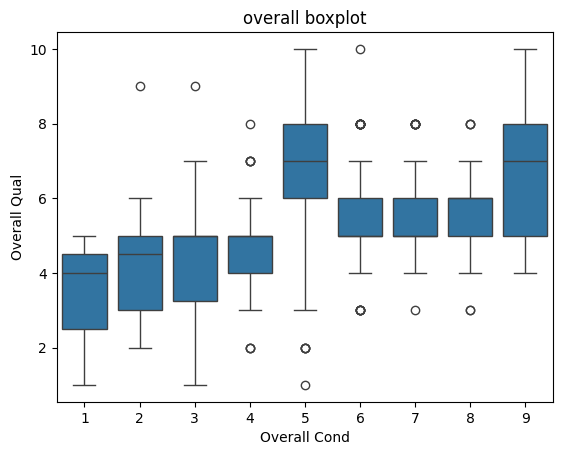

In [10]:
# this is Overall Cond boxplot
df.boxplot(column="Overall Cond")
plt.title("Cond boxplot")
plt.show()

# this is Overall Qual boxplot
df.boxplot(column="Overall Qual")
plt.title("Qual boxplot")
plt.show()

# here all of them (Qual,Cond)
sns.boxplot(x=df["Overall Cond"], y=df["Overall Qual"], data=df)
plt.title("overall boxplot")

<Axes: >

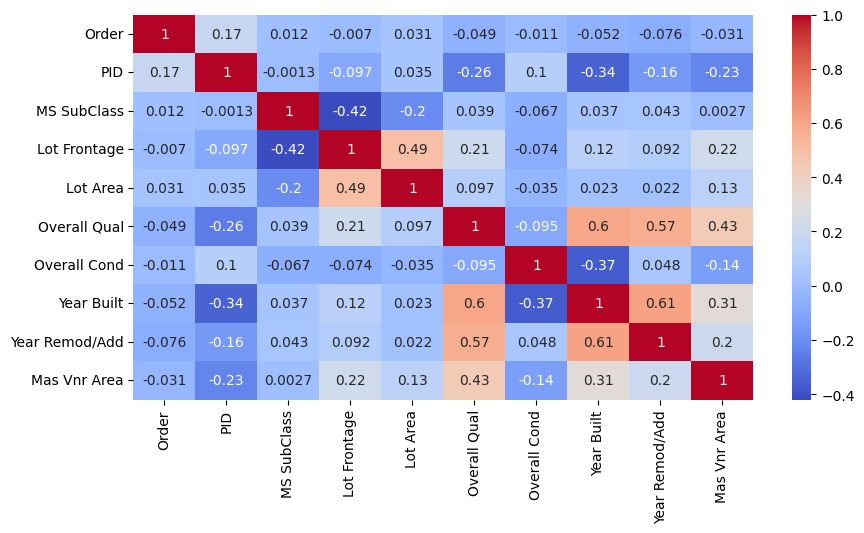

In [11]:
# i used ai
# here he chose the colunms that have numbers
corr_matrix = df.select_dtypes(include=['number']).corr()
# here the top 10 futures
top_10= corr_matrix['SalePrice'].head(10).index
top_corr = corr_matrix.loc[top_10, top_10]

plt.figure(figsize=(10,5))
sns.heatmap(top_corr, annot=True, cmap='coolwarm', )


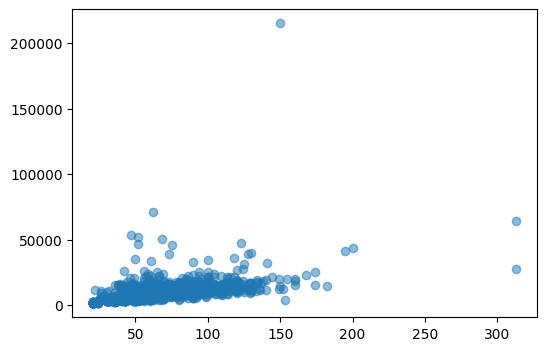

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(x=df["Lot Frontage"],y=df["Lot Area"], alpha=0.5)


In [13]:
gropby_df=df.groupby("Year Built")["Yr Sold"].agg(["count","mean"])
print(gropby_df)

            count         mean
Year Built                    
1872            1  2008.000000
1875            1  2010.000000
1879            1  2007.000000
1880            5  2007.800000
1882            1  2009.000000
...           ...          ...
2006          138  2007.065217
2007          109  2007.825688
2008           49  2008.795918
2009           25  2009.520000
2010            3  2010.000000

[118 rows x 2 columns]


In paragraph 1, It explained the Mas Vnr Area column, showing where the data is collected and where it veers off,using histplot.

In paragraph 2, It explained the Overall Qual column, showing where the data is collected and where it veers off, using histplot.

In paragraph 3, It explained theLot Frontage column, showing where the data is collected and where it veers off,using kdeplot.

In paragraph 4, there are 3 shapes: the first one shows column Overall Cond, the second one shows column Overall Qual, and the third one shows Overall Cond and Overall Qual together.it show where the main values and the outliers values .

In Paragraph 5, explains the extent to which data containing numbers are related to a single objective.

In paragraph 6, it explains where the data is collected and what the outlier values ​​are in column Lot Frontage.

In [14]:
# Here data was recorded from the dataframe to the array
mo=df["Mo Sold"]
s=np.array([mo])
print(s)
# This is where the process of collecting enemies begins
for i in mo:
  i=i+i
#After adding them up, we check the result so we can divide by their number.
if i==0 :
  print("Error")
elif len(mo)==2930:
  i/2930
  print(f"mean={i}")
else:
  print("there are 0 in num")

print(f"std={mo.std()}")

[[ 5  6  6 ...  7  4 11]]
mean=22
std=2.714492425430169


In [15]:
# i used ai to debug the reshape and to but one colunm (Overall cond) in StandardScaler
cond=df["Overall Cond"]
x=np.array([cond]).reshape(-1, 1)

means=x.mean(axis=0,keepdims=True)
stds=x.std(axis=0,keepdims=True)
x_std=(x-means)/ stds
print(x_std)

from sklearn.preprocessing import StandardScaler
# here I used StandardScaler()
std_scaler=StandardScaler()
# here I copied the (df)
df_std=df.copy()
df_std["Overall Cond_std"]=std_scaler.fit_transform(df_std[["Overall Cond"]])
print(df_std[["Overall Cond","Overall Cond_std"]])

# there is no difference between them

[[-0.50671843]
 [ 0.39309066]
 [ 0.39309066]
 ...
 [-0.50671843]
 [-0.50671843]
 [-0.50671843]]
      Overall Cond  Overall Cond_std
0                5         -0.506718
1                6          0.393091
2                6          0.393091
3                5         -0.506718
4                5         -0.506718
...            ...               ...
2925             6          0.393091
2926             5         -0.506718
2927             5         -0.506718
2928             5         -0.506718
2929             5         -0.506718

[2930 rows x 2 columns]


In [16]:
a1=df["Lot Frontage"]
b1=df["Lot Area"]


a2=np.array([a1])
b2=np.array([b1])

def cosine_similarity(a, b):
  return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
print("cos(u, v):", cosine_similarity(u, v))
# Two directions are perpendicular because the result is 0

cos(u, v): 0.0


In [17]:
# i used ai and he told me how to get the largest value and lowest value and in cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity

top_v=df["Overall Cond"].idxmax()
low_v=df["Overall Cond"].idxmin()

df_num=df.select_dtypes(include=['number']).fillna(0)


v1=df_num.loc[[top_v]].values
v2=df_num.loc[[low_v]].values

sim= cosine_similarity(v1, v2)

print(f"cosine similarity={sim[0][0]}")


cosine similarity=0.999999998006972


In [18]:
# i used ai 
quality_threshold = 8
price_threshold = 300000

high_q_items = df[df['Overall Qual'] >= quality_threshold]
total_high_q = len(high_q_items)

above_threshold = high_q_items[high_q_items['SalePrice'] > price_threshold]
count_above = len(above_threshold)

probability = count_above / total_high_q
print(f"={probability:.2%}")

=43.24%
